# World Happiness Report — Exploratory Data Analysis

## Dataset
153 countries · 12 columns · Source: World Happiness Report 2017

## Key Questions Explored
- Which countries and regions are happiest?
- Which factors most strongly predict happiness?
- How does happiness vary within regions?

## Key Findings
- Top 5 happiest: Norway, Denmark, Iceland, Switzerland, Finland (all Scandinavian)
- Bottom 5: Central African Republic, Burundi, Tanzania, Syria, Rwanda
- Economy (0.81) and Job Satisfaction (0.81) are the strongest predictors of happiness
- Generosity is the weakest predictor (0.16) — counterintuitive finding
- Freedom (0.58) does not separate happy from unhappy countries as much as assumed
- Central African Republic scores 0 on both Economy and Family — complete societal breakdown
- North America least variation in happiness · Africa highest variation
- Europe anomaly: unusually low Freedom score — likely a data grouping artifact

## Techniques Used
Pandas, SQL (GROUP BY, HAVING, subqueries), Matplotlib, Seaborn
Bar chart, heatmap, regplot, boxplot, horizontal bar chart

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

url='https://raw.githubusercontent.com/datasets/country-list/master/data.csv'

df=pd.read_csv('https://raw.githubusercontent.com/PhilippeCodes/World-Happiness-Report-Data-Analysis/master/World%20Happiness%20Report.csv')

print(df.head())
print(df.shape)
print(df.columns.tolist())

       Country  Happiness Rank  Happiness Score   Economy    Family    Health  \
0       Norway               1            7.537  1.616463  1.533524  0.796667   
1      Denmark               2            7.522  1.482383  1.551122  0.792566   
2      Iceland               3            7.504  1.480633  1.610574  0.833552   
3  Switzerland               4            7.494  1.564980  1.516912  0.858131   
4      Finland               5            7.469  1.443572  1.540247  0.809158   

    Freedom  Generosity  Corruption  Dystopia  Job Satisfaction  \
0  0.635423    0.362012    0.315964  2.277027              94.6   
1  0.626007    0.355280    0.400770  2.313707              93.5   
2  0.627163    0.475540    0.153527  2.322715              94.5   
3  0.620071    0.290549    0.367007  2.276716              93.7   
4  0.617951    0.245483    0.382612  2.430182              91.2   

           Region  
0  Western Europe  
1  Western Europe  
2  Western Europe  
3  Western Europe  
4  Western

In [6]:
print(df.isnull().sum())

Country             0
Happiness Rank      0
Happiness Score     0
Economy             0
Family              0
Health              0
Freedom             0
Generosity          0
Corruption          0
Dystopia            0
Job Satisfaction    2
Region              0
dtype: int64


In [7]:
df['Job Satisfaction']=df['Job Satisfaction'].fillna(df['Job Satisfaction'].mean())
print(df.isnull().sum())

Country             0
Happiness Rank      0
Happiness Score     0
Economy             0
Family              0
Health              0
Freedom             0
Generosity          0
Corruption          0
Dystopia            0
Job Satisfaction    0
Region              0
dtype: int64


In [10]:
print(df.shape)
print(df.dtypes)

(153, 12)
Country                 str
Happiness Rank        int64
Happiness Score     float64
Economy             float64
Family              float64
Health              float64
Freedom             float64
Generosity          float64
Corruption          float64
Dystopia            float64
Job Satisfaction    float64
Region                  str
dtype: object


In [26]:
from pandasql import sqldf
print("BOTTOM 5 HAPPIEST COUNTRIES:\n")
query='''SELECT Country, `Happiness Rank`
FROM df
ORDER BY `Happiness Rank` DESC
LIMIT 5
'''
result=sqldf(query)
print(result)

print("\nTOP 5 HAPPIEST COUNTRIES:\n")

query='''SELECT Country, `Happiness Rank`
FROM df
ORDER BY `Happiness Rank` ASC
LIMIT 5
'''
result=sqldf(query)
print(result)

BOTTOM 5 HAPPIEST COUNTRIES:

                    Country  Happiness Rank
0  Central African Republic             155
1                   Burundi             154
2                  Tanzania             153
3                     Syria             152
4                    Rwanda             151

TOP 5 HAPPIEST COUNTRIES:

       Country  Happiness Rank
0       Norway               1
1      Denmark               2
2      Iceland               3
3  Switzerland               4
4      Finland               5


In [24]:
query='''SELECT Region, AVG(`Happiness Score`) as avg_happiness
FROM df
GROUP BY Region 
ORDER BY avg_happiness DESC
LIMIT 1
'''
result=sqldf(query)
print(result)

          Region  avg_happiness
0  North America         7.1545


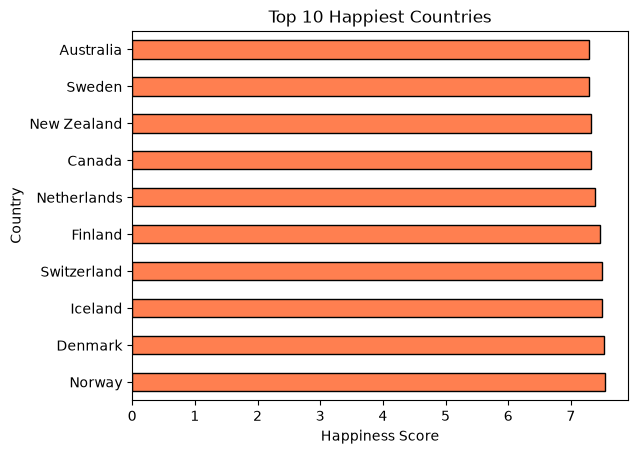

In [36]:

top_10_happiest=df.nlargest(10,'Happiness Score')[['Country','Happiness Score']]
top_10_happiest=top_10_happiest.set_index('Country')
top_10_happiest.plot(kind='barh',color='coral',edgecolor='black')
plt.title('Top 10 Happiest Countries')
plt.xlabel('Happiness Score')
plt.ylabel('Country')
plt.legend().remove()
plt.show()

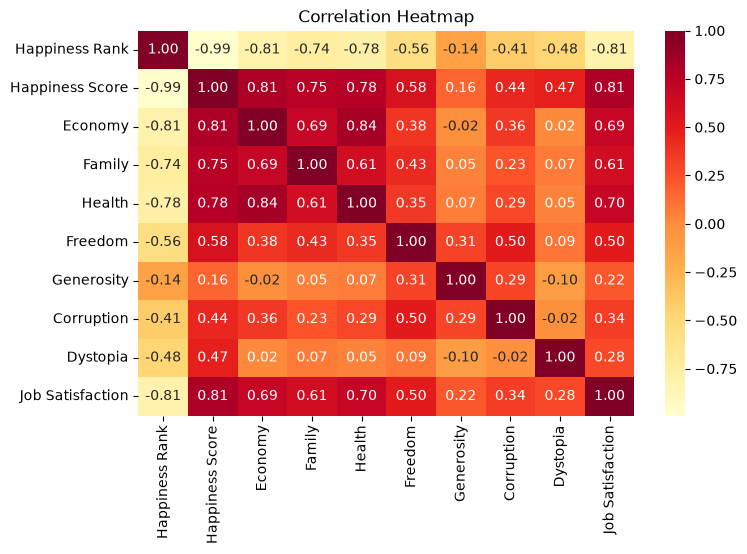

In [38]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='YlOrRd')
plt.title('Correlation Heatmap')
plt.show()

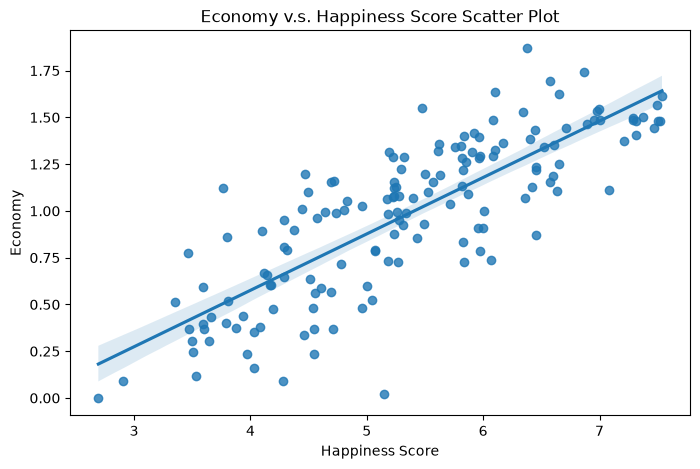

In [39]:
plt.figure(figsize=(8,5))
sns.regplot(x='Happiness Score', y='Economy', data=df)
plt.title('Economy v.s. Happiness Score Scatter Plot')
plt.xlabel('Happiness Score')
plt.ylabel("Economy")
plt.show()

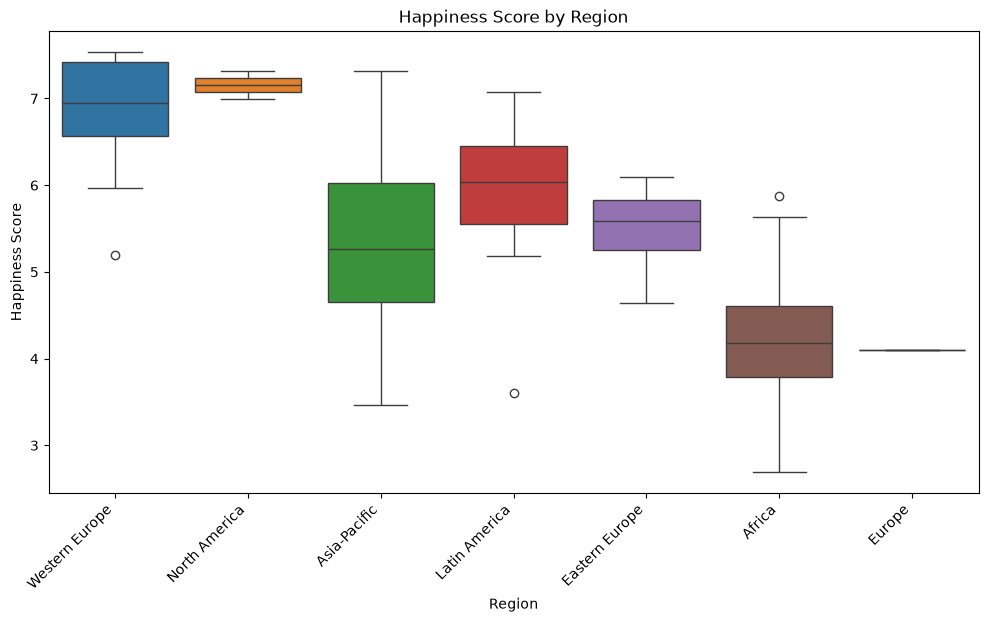

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Region',y='Happiness Score', hue='Region',data=df)
plt.title('Happiness Score by Region')
plt.xlabel('Region')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.show()

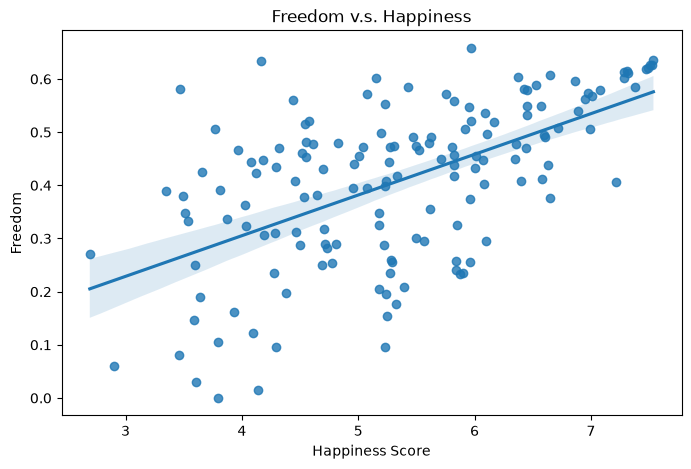

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

url='https://raw.githubusercontent.com/datasets/country-list/master/data.csv'

df=pd.read_csv('https://raw.githubusercontent.com/PhilippeCodes/World-Happiness-Report-Data-Analysis/master/World%20Happiness%20Report.csv')

plt.figure(figsize=(8,5))
sns.regplot(x='Happiness Score', y='Freedom', data=df)
plt.title('Freedom v.s. Happiness')
plt.xlabel('Happiness Score')
plt.ylabel('Freedom')
plt.show()

In [2]:
from pandasql import sqldf
import warnings
warnings.filterwarnings('ignore')
query='''SELECT Region, AVG(Economy) as avg_economy, AVG(Freedom) as avg_freedom, AVG(Health) as avg_health, AVG(Generosity) as avg_generosity
FROM df
GROUP BY Region
ORDER BY avg_economy DESC
'''
result=sqldf(query)
print(result)

           Region  avg_economy  avg_freedom  avg_health  avg_generosity
0   North America     1.512732     0.558421    0.804422        0.414059
1  Western Europe     1.471893     0.546660    0.820159        0.311760
2  Eastern Europe     1.185771     0.318793    0.688783        0.174958
3    Asia-Pacific     1.059272     0.429932    0.608605        0.294002
4   Latin America     1.006981     0.449222    0.611009        0.210696
5          Europe     0.894652     0.122975    0.575904        0.270061
6          Africa     0.559931     0.352025    0.264426        0.213328


In [3]:

print(df.corr(numeric_only=True)['Happiness Score'].sort_values())

Happiness Rank     -0.992782
Generosity          0.160010
Corruption          0.435854
Dystopia            0.474300
Freedom             0.576027
Family              0.753815
Health              0.780496
Economy             0.811194
Job Satisfaction    0.812873
Happiness Score     1.000000
Name: Happiness Score, dtype: float64


In [4]:

top5 = df.nsmallest(5, 'Happiness Rank')[['Country','Economy','Health','Freedom','Family']]
bottom5 = df.nlargest(5, 'Happiness Rank')[['Country','Economy','Health','Freedom','Family']]
print(top5)
print(bottom5)

       Country   Economy    Health   Freedom    Family
0       Norway  1.616463  0.796667  0.635423  1.533524
1      Denmark  1.482383  0.792566  0.626007  1.551122
2      Iceland  1.480633  0.833552  0.627163  1.610574
3  Switzerland  1.564980  0.858131  0.620071  1.516912
4      Finland  1.443572  0.809158  0.617951  1.540247
                      Country   Economy    Health   Freedom    Family
152  Central African Republic  0.000000  0.018773  0.270842  0.000000
151                   Burundi  0.091623  0.151611  0.059901  0.629794
150                  Tanzania  0.511136  0.364509  0.390018  1.041990
149                     Syria  0.777153  0.500533  0.081539  0.396103
148                    Rwanda  0.368746  0.326425  0.581844  0.945707
